In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split   
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [2]:
df = pd.read_csv('../data/gym_churn_us.csv')

In [3]:
caida_frecuencia = df['Avg_class_frequency_total'] - df['Avg_class_frequency_current_month']
df['caida_frecuencia'] = caida_frecuencia

In [4]:
df.isnull().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
caida_frecuencia                     0
dtype: int64

array([[<Axes: title={'center': 'gender'}>,
        <Axes: title={'center': 'Near_Location'}>,
        <Axes: title={'center': 'Partner'}>,
        <Axes: title={'center': 'Promo_friends'}>],
       [<Axes: title={'center': 'Phone'}>,
        <Axes: title={'center': 'Contract_period'}>,
        <Axes: title={'center': 'Group_visits'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Avg_additional_charges_total'}>,
        <Axes: title={'center': 'Month_to_end_contract'}>,
        <Axes: title={'center': 'Lifetime'}>,
        <Axes: title={'center': 'Avg_class_frequency_total'}>],
       [<Axes: title={'center': 'Avg_class_frequency_current_month'}>,
        <Axes: title={'center': 'Churn'}>,
        <Axes: title={'center': 'caida_frecuencia'}>, <Axes: >]],
      dtype=object)

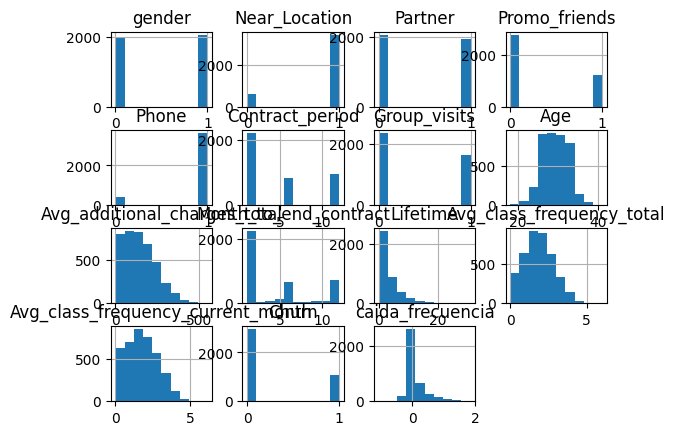

In [5]:
df.hist()

Para normalizar los datos dependiendo de la distribución de cada uno de estos:

In [6]:
X = df.drop(columns=['Churn', 'Avg_class_frequency_total', 'Phone', 'gender'])
y = df['Churn']

In [7]:
print(len(X.columns))

11


In [8]:
columnas_campana = ['Age','Avg_class_frequency_current_month', 'caida_frecuencia']
columnas_sesgadas_o_fijas = ['Lifetime', 'Avg_additional_charges_total', 'Contract_period', 'Month_to_end_contract']

In [9]:
preprocesador = ColumnTransformer(
    transformers=[
        ('estandarizacion', StandardScaler(), columnas_campana),
        ('normalizacion', MinMaxScaler(), columnas_sesgadas_o_fijas)
    ],
    remainder='passthrough' 
)

In [10]:
X_escalado = preprocesador.fit_transform(X)

In [11]:
y.value_counts()

Churn
0    2939
1    1061
Name: count, dtype: int64

In [12]:
ros = RandomOverSampler()
X_ros, y_ros = ros.fit_resample(X_escalado, y)

rus = RandomUnderSampler()
X_rus, y_rus = rus.fit_resample(X_escalado, y)

smote = SMOTE()
X_smote, y_smote = smote.fit_resample(X_escalado, y)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.3, random_state=100)

In [14]:
y_train_dum = pd.get_dummies(y_train)
y_test_dum = pd.get_dummies(y_test)

In [15]:
y_test_dum.value_counts()

0      1    
False  True     890
True   False    874
Name: count, dtype: int64

Entrenamiento de la red neuronal

In [16]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

In [17]:
X_val_tensor = torch.tensor(X_test, dtype=torch.float32)
y_val_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

In [18]:
BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [19]:
import torch.nn as nn
import torch.optim as optim

class RedPrediccionChurn(nn.Module):
    def __init__(self, input_dim):
        super(RedPrediccionChurn, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Dropout(0.1), 
            
            nn.Linear(10, 5),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Linear(5, 2),
            nn.ReLU(),
        )
        
    def forward(self, x):
        return self.network(x)


num_caracteristicas = 11 
modelo = RedPrediccionChurn(input_dim=num_caracteristicas)

optimizador = optim.Adam(modelo.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [20]:
EPOCHS = 45

for epoch in range(EPOCHS):
    modelo.train() 
    loss_acumulada = 0.0
    for lote_X, lote_y in train_loader:
        optimizador.zero_grad()
        predicciones = modelo(lote_X)
        loss = criterion(predicciones, lote_y)
        loss.backward()
        optimizador.step()
        loss_acumulada += loss.item() * lote_X.size(0)
    
    loss_total_epoca = loss_acumulada / len(train_loader.dataset)
    

    if (epoch + 1) % 5 == 0 or epoch == 0:
        modelo.eval() 
        with torch.no_grad():
            pred_val = modelo(X_val_tensor)
            clases_predichas = torch.argmax(pred_val, dim=1) 
            accuracy = (clases_predichas.float() == y_val_tensor.flatten()).float().mean()
            
        print(f"Época [{epoch+1}/{EPOCHS}] -> Pérdida Entrenamiento: {loss_total_epoca:.4f} | Precisión Validación: {accuracy.item()*100:.2f}%")

Época [1/45] -> Pérdida Entrenamiento: 0.6752 | Precisión Validación: 68.08%
Época [5/45] -> Pérdida Entrenamiento: 0.5067 | Precisión Validación: 87.13%
Época [10/45] -> Pérdida Entrenamiento: 0.2737 | Precisión Validación: 88.27%
Época [15/45] -> Pérdida Entrenamiento: 0.2157 | Precisión Validación: 91.44%
Época [20/45] -> Pérdida Entrenamiento: 0.1843 | Precisión Validación: 93.99%
Época [25/45] -> Pérdida Entrenamiento: 0.1621 | Precisión Validación: 94.61%
Época [30/45] -> Pérdida Entrenamiento: 0.1527 | Precisión Validación: 94.90%
Época [35/45] -> Pérdida Entrenamiento: 0.1492 | Precisión Validación: 94.84%
Época [40/45] -> Pérdida Entrenamiento: 0.1392 | Precisión Validación: 94.95%
Época [45/45] -> Pérdida Entrenamiento: 0.1392 | Precisión Validación: 95.29%



--- REPORTE FINAL DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

    Se queda       0.95      0.95      0.95       874
       Se va       0.95      0.95      0.95       890

    accuracy                           0.95      1764
   macro avg       0.95      0.95      0.95      1764
weighted avg       0.95      0.95      0.95      1764



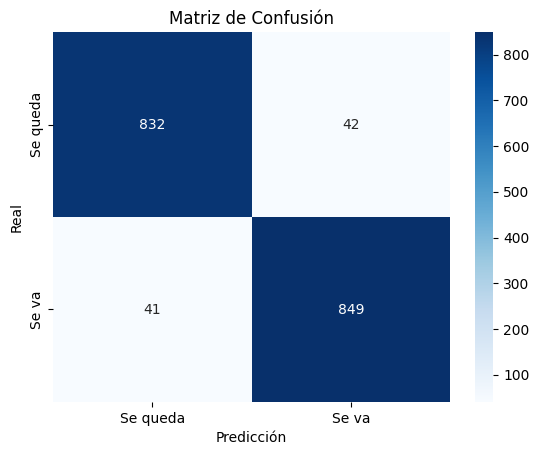

In [21]:
modelo.eval()
with torch.no_grad():
    pred_finales = modelo(X_val_tensor)
    y_pred = torch.argmax(pred_finales, dim=1).numpy()
    y_true = y_val_tensor.flatten().numpy()

print("\n--- REPORTE FINAL DE CLASIFICACIÓN ---")
print(classification_report(y_true, y_pred, target_names=['Se queda', 'Se va']))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Se queda', 'Se va'], yticklabels=['Se queda', 'Se va'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

prueba con datos para un cliente

In [28]:
cliente = {
    'Near_Location': 1,
    'Partner': 0,
    'Promo_friends': 1,
    'Contract_period': 12,
    'Group_visits': 0,
    'Age': 23,
    'Avg_additional_charges_total': 0,
    'Month_to_end_contract': 1,
    'Lifetime':30,
    'Avg_class_frequency_current_month': 4,
    'caida_frecuencia': 1
}

In [29]:
df_cliente = pd.DataFrame([cliente])

In [30]:
datos_procesados = preprocesador.transform(df_cliente)

In [31]:
input_tensor = torch.tensor(datos_procesados, dtype=torch.float32)

In [32]:
modelo.eval()
with torch.no_grad():
    output = modelo(input_tensor)
    prediccion = torch.argmax(output, dim=1)
    probabilidades = torch.softmax(output, dim=1).squeeze()
    prediccion_clase = torch.argmax(probabilidades).item()
    prob_abandono = probabilidades[1].item()
    resultado_final = {
    "prediccion": int(prediccion_clase),
    "probabilidad_abandono": float(prob_abandono)
}
    print(resultado_final)
print(f"Predicción del modelo (índice de clase): {prediccion.item()}")

{'prediccion': 0, 'probabilidad_abandono': 2.6396330454758754e-08}
Predicción del modelo (índice de clase): 0
